# MHD Equilibrium Analysis

## Overview

A reconstructed equilibrium is the object almost every later stage reads: the
stability codes take its flux map, the comparison pages take its descriptors,
the profile work takes its coordinates. This notebook loads one, checks that its
conventions are what they claim to be, and derives the quantities those stages
ask for -- scalars, profiles, flux-surface geometry, coordinate maps and a field
line -- from the packaged VEST sample alone. No database, no external code.

Everything here comes from `vaft.process.equilibrium` and the ODS plot adapters.
Where a quantity is unavailable it is reported as unavailable rather than filled
in.

## Pipeline context

Downstream of EFIT reconstruction
(`magnetic_equilibrium_reconstruction_with_efit.ipynb`), upstream of the ideal,
resistive and perturbed-response stability stages
(`linear_ideal_stability_analysis_with_dcon.ipynb`,
`linear_resistive_stability_analysis_with_rdcon.ipynb`,
`perturbed_equilibrium_and_3d_response_with_gpec.ipynb`). For the same analysis
across machines, see `multiple_tokamak_comparison.ipynb`.

## Equilibrium data loading

`vaft.omas.load` reads the packaged shot; `as_equilibrium` adapts one time slice
into the neutral `EquilibriumData` the processing layer works with. The same two
calls accept a GEQDSK file or an IMAS netCDF entry -- the format is decided by
content, not by this notebook.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import vaft
from vaft.data.eqdsk import ods_psi_to_wb_per_radian_factor
from vaft.process.equilibrium import (
    as_equilibrium,
    derive_global_descriptors,
    flux_surface_quantities,
    make_equilibrium_field_interpolator,
    psi_to_rho,
    trace_field_line,
)

SHOT = 39915
ods = vaft.omas.load(vaft.data.sample(SHOT, representation="omas"))
slices = ods["equilibrium.time_slice"]
times = np.asarray(ods["equilibrium.time"], dtype=float)
currents = np.array([
    float(slices[i]["global_quantities.ip"])
    if "global_quantities" in slices[i] and "ip" in slices[i]["global_quantities"]
    else np.nan
    for i in range(len(slices))
])

# The peak-current slice, not slice zero: a reconstruction is worth analysing
# where the discharge actually is.
index = int(np.nanargmax(np.abs(currents)))
equilibrium = as_equilibrium(ods, time_index=index)

print(f"shot {SHOT}: {len(slices)} equilibrium slices, {times[0]:.3f}-{times[-1]:.3f} s")
for i, (t, ip) in enumerate(zip(times, currents)):
    mark = " <- analysed" if i == index else ""
    print(f"  {i}  t={t:.3f} s  Ip={ip / 1e3:8.1f} kA{mark}")

<repo>/vaft/omas/__init__.py:111: RuntimeWarning: Could not infer an IMAS DD version for omas_json; using 3.41.0


shot 39915: 9 equilibrium slices, 0.316-0.331 s
  0  t=0.316 s  Ip=    80.1 kA <- analysed
  1  t=0.317 s  Ip=    80.0 kA
  2  t=0.318 s  Ip=    79.4 kA
  3  t=0.319 s  Ip=    79.0 kA
  4  t=0.320 s  Ip=    78.6 kA
  5  t=0.323 s  Ip=    62.8 kA
  6  t=0.325 s  Ip=    51.0 kA
  7  t=0.326 s  Ip=    46.2 kA
  8  t=0.331 s  Ip=     0.0 kA


## Equilibrium metadata and validation

Before anything is derived from it, the equilibrium says which convention it is
in and what it is missing. COCOS is identified from the data's own signs;
`(1, 2)` means the two candidates differ only in a sign VEST's stored fields
cannot distinguish, which is reported rather than silently resolved.

In [ ]:
convention = equilibrium.convention
print(f"COCOS candidates      {convention.identified}   (evidence: {convention.source})")
print(f"psi per radian        {convention.psi_per_radian}")
print(f"sgn(Ip), sgn(Bt), sgn(q)  {convention.ip_sign}, {convention.bt_sign}, {convention.q_sign}")
print(f"psi -> Wb/rad factor  {ods_psi_to_wb_per_radian_factor(ods, index)}")
print()
print(f"grid                  {equilibrium.r.size} x {equilibrium.z.size}"
      f"  R=[{equilibrium.r[0]:.3f}, {equilibrium.r[-1]:.3f}] m"
      f"  Z=[{equilibrium.z[0]:.3f}, {equilibrium.z[-1]:.3f}] m")
print(f"magnetic axis         ({equilibrium.magnetic_axis[0]:.4f}, {equilibrium.magnetic_axis[1]:+.4f}) m")
print(f"psi axis / boundary   {equilibrium.psi_axis:+.6f} / {equilibrium.psi_boundary:+.6f} Wb/rad")
print(f"LCFS points           {equilibrium.lcfs.r.size}")
print(f"limiter points        {equilibrium.limiter.r.size if equilibrium.limiter is not None else 'not carried'}")

descriptors = derive_global_descriptors(equilibrium)
issues = [issue.message for issue in descriptors.validation.issues]
print()
print("validation:", issues if issues else "no issues")

COCOS candidates      (1, 2)   (evidence: ODS signs + phi/q slope family detection)
psi per radian        True
sgn(Ip), sgn(Bt), sgn(q)  1, 1, 1
psi -> Wb/rad factor  1.0

grid                  129 x 129  R=[0.050, 1.200] m  Z=[-1.500, 1.500] m
magnetic axis         (0.4273, +0.0234) m
psi axis / boundary   -0.002972 / +0.000240 Wb/rad
LCFS points           105
limiter points        17

validation: ['COCOS is ambiguous ((1, 2)); pass convention= explicitly before conversion']


## Representative scalar quantities

Each descriptor carries its unit, its definition and how it was derived, so a
number can be traced back to the operation that produced it. A quantity the
equilibrium cannot support comes back unavailable, with the reason.

In [ ]:
report = (
    ("ip", 1e-3, "kA"), ("bt0", 1.0, "T"), ("major_radius", 1.0, "m"),
    ("minor_radius", 1.0, "m"), ("inverse_aspect_ratio", 1.0, "-"),
    ("elongation", 1.0, "-"), ("triangularity_upper", 1.0, "-"),
    ("triangularity_lower", 1.0, "-"), ("volume", 1.0, "m^3"),
    ("cross_section_area", 1.0, "m^2"), ("q0", 1.0, "-"), ("q95", 1.0, "-"),
    ("q_edge", 1.0, "-"), ("beta_t", 1.0, "-"), ("beta_n", 1.0, "-"),
    ("li_virial", 1.0, "-"), ("shafranov_shift", 1.0, "m"),
    ("magnetic_shear", 1.0, "-"),
)
def scalar(item, scale):
    """Descriptors are mostly scalars; a few are profiles, so say which."""
    value = np.asarray(item.value, dtype=float)
    if value.ndim == 0:
        return f"{float(value) * scale:12.4g}"
    return f"{value.size:d}-point profile".rjust(12)

for name, scale, unit in report:
    item = descriptors[name]
    if item.available:
        print(f"{name:22s} {scalar(item, scale)} {unit:12s} [{item.provenance.method}]")
    else:
        print(f"{name:22s} {'--':>12s} {unit:12s} {item.reason}")

ip                            80.07 kA           [source]
bt0                          0.1496 T            [source]
major_radius                 0.3989 m            [closed-polygon geometry]
minor_radius                 0.2949 m            [closed-polygon geometry]
inverse_aspect_ratio         0.7391 -            [closed-polygon geometry]
elongation                    1.536 -            [closed-polygon geometry]
triangularity_upper          0.3302 -            [closed-polygon geometry]
triangularity_lower          0.3302 -            [closed-polygon geometry]
volume                       0.9559 m^3          [closed-polygon geometry]
cross_section_area           0.4099 m^2          [closed-polygon geometry]
q0                             2.46 -            [profile endpoint]
q95                           8.671 -            [linear interpolation]
q_edge                        11.73 -            [profile endpoint]
beta_t                     0.001274 -            [volume and pressure integr

## Profile quantities

An EFIT g-file stores a handful of one-dimensional profiles; the rest of what
the transport and stability stages want -- the flux-surface averages, the
current density, the toroidal flux -- has to be derived from the flux map.
`update_equilibrium_derived_profiles` does that in place, and says which slices
it could not do it for.

In [ ]:
before = set(ods["equilibrium.time_slice"][index]["profiles_1d"].keys())
vaft.omas.update_equilibrium_derived_profiles(ods)
after = set(ods["equilibrium.time_slice"][index]["profiles_1d"].keys())

print("stored by the reconstruction:", ", ".join(sorted(before)))
print()
print("derived by VAFT:            ", ", ".join(sorted(after - before)))

equilibrium.time_slice.8 has a degenerate psi range; skipping.


equilibrium.time_slice.8 has a degenerate psi range; skipping.


equilibrium.time_slice.8 has a degenerate psi range; skipping.


profiles_1d.area not found for time slice 8


boundary.outline not found for time slice 8


equilibrium.time_slice.8 has a degenerate psi range; skipping.


stored by the reconstruction: dpressure_dpsi, f, f_df_dpsi, phi, pressure, psi, q, rho_tor_norm

derived by VAFT:             area, b_field_max, b_field_min, darea_dpsi, dvolume_dpsi, elongation, gm1, gm5, gm8, gm9, j_tor, rho_tor, surface, triangularity_lower, triangularity_upper, volume


The profiles, drawn through the canonical adapters rather than notebook-local
Matplotlib. `q` uses VAFT's intuitive sign policy, which flips a profile whose
stored sign is a convention and says so in the title; the rest are shown exactly
as stored.

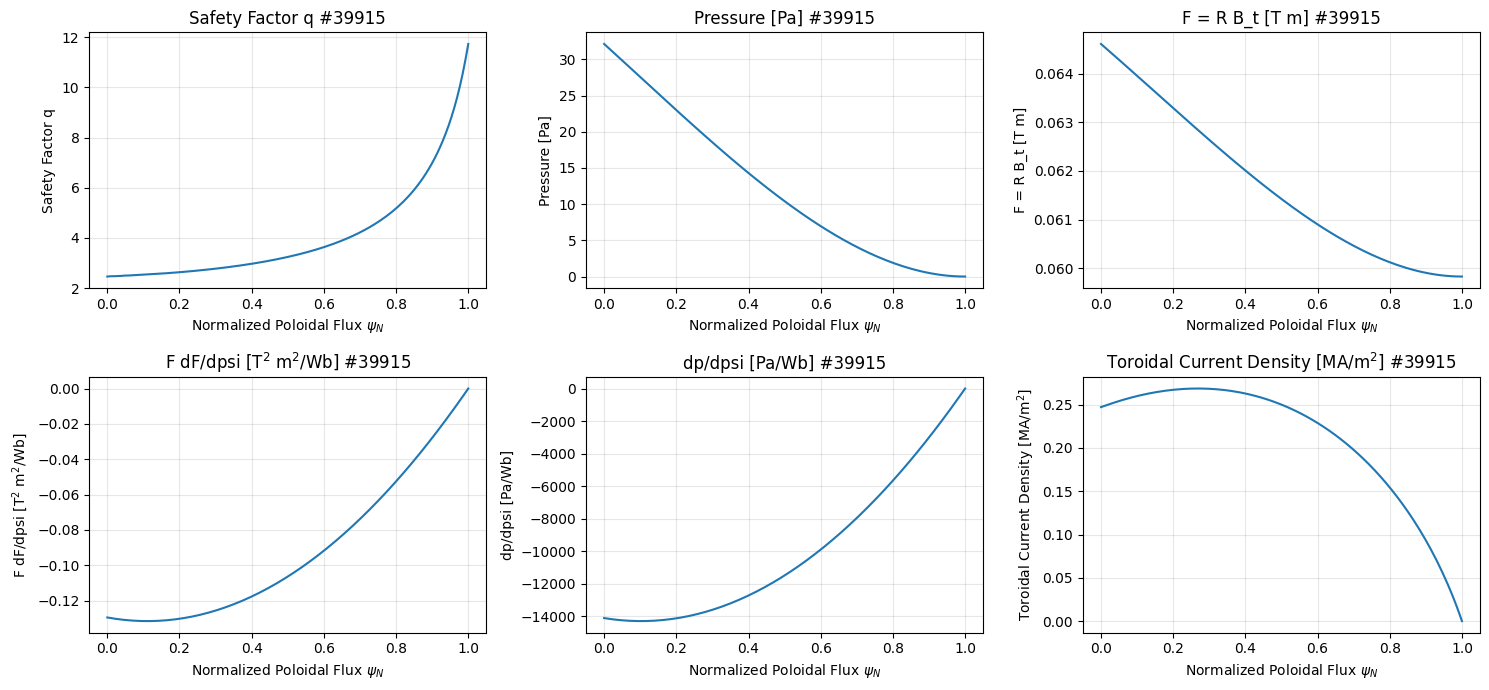

In [ ]:
panels = (
    ("equilibrium_profile_q", "intuitive"),
    ("equilibrium_profile_pressure", "canonical"),
    ("equilibrium_profile_f", "canonical"),
    ("equilibrium_profile_ffprime", "canonical"),
    ("equilibrium_profile_pprime", "canonical"),
    ("equilibrium_profile_j_tor", "canonical"),
)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (name, orientation) in zip(axes.ravel(), panels):
    vaft.omas.render_plot(
        name, ods, label=[str(SHOT)], coordinate="psi_norm",
        time_slice=index, orientation=orientation, ax=ax,
    )
fig.tight_layout()
plt.show()

## Coordinate transformations

Three radial coordinates appear across VAFT's equilibrium products: normalized
poloidal flux, normalized poloidal radius, and normalized toroidal flux. The
derivation layer supplies all three with their definitions, and `psi_to_rho`
integrates the q profile to convert a single flux value the same way.

In [ ]:
for name, item in descriptors.radial_coordinates.items():
    state = "available" if item.available else f"unavailable ({item.reason})"
    print(f"{name:12s} {state:24s} {item.definition}")

psi_1d = equilibrium.psi_1d
psi_norm = (psi_1d - psi_1d[0]) / (psi_1d[-1] - psi_1d[0])
q_of_psi_norm = interp1d(psi_norm, equilibrium.q, kind="cubic", fill_value="extrapolate")

print()
print(f"{'psi_N':>8s} {'psi [Wb/rad]':>14s} {'rho_pol_N':>10s} {'rho_tor_N (q-integral)':>24s}")
for level in (0.0, 0.25, 0.5, 0.75, 0.95, 1.0):
    psi = equilibrium.psi_axis + level * (equilibrium.psi_boundary - equilibrium.psi_axis)
    rho_tor = psi_to_rho(psi, q_of_psi_norm, equilibrium.psi_axis, equilibrium.psi_boundary)
    print(f"{level:8.2f} {psi:14.6f} {np.sqrt(level):10.4f} {rho_tor:24.4f}")

psi_n        available                (psi-psi_axis)/(psi_boundary-psi_axis)
rho_pol_n    available                sqrt(psi_n)
rho_tor_n    available                sqrt(int_axis^psi q dpsi / int_axis^boundary q dpsi)

   psi_N   psi [Wb/rad]  rho_pol_N   rho_tor_N (q-integral)
    0.00      -0.002972     0.0000                   0.0000
    0.25      -0.002169     0.5000                   0.3973
    0.50      -0.001366     0.7071                   0.5818
    0.75      -0.000563     0.8660                   0.7573
    0.95       0.000079     0.9747                   0.9362
    1.00       0.000240     1.0000                   1.0000


## Flux-surface visualization

`flux_surface_quantities` traces each normalized-flux level and returns the
flux-surface averages the transport and stability stages consume -- volume,
area, the `gm*` metric averages, and the shape of each surface. It wants psi in
weber per radian, which is why the factor above is applied rather than assumed.

The axis level is a point and the boundary level is taken from the stored
outline; both are handled by the routine rather than by this page.

In [ ]:
levels = np.array([0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0])
factor = ods_psi_to_wb_per_radian_factor(ods, index)
f_on_levels = np.interp(levels, psi_norm, equilibrium.f)

surfaces = flux_surface_quantities(
    equilibrium.psi * factor,
    equilibrium.r,
    equilibrium.z,
    equilibrium.psi_axis * factor,
    equilibrium.psi_boundary * factor,
    levels,
    f_profile=f_on_levels,
    axis_rz=equilibrium.magnetic_axis,
    boundary=(equilibrium.lcfs.r, equilibrium.lcfs.z),
)

columns = ("volume", "area", "length_pol", "r_inboard", "r_outboard",
           "elongation", "triangularity_upper", "gm1", "gm9")
head = f"{'psi_N':>6s}" + "".join(f"{name:>13s}" for name in columns)
print(head)
print("-" * len(head))
for row, level in enumerate(levels):
    print(f"{level:6.2f}" + "".join(f"{surfaces[name][row]:13.4g}" for name in columns))

# The same quantity reached two ways: traced here, and derived into the ODS by
# update_equilibrium_derived_profiles above.
stored = ods["equilibrium.time_slice"][index]["profiles_1d"]
stored_volume = np.interp(levels, psi_norm, np.asarray(stored["volume"], dtype=float))
print()
print(f"{'psi_N':>6s} {'volume traced':>15s} {'volume in ODS':>15s}")
for row, level in enumerate(levels):
    print(f"{level:6.2f} {surfaces['volume'][row]:15.5g} {stored_volume[row]:15.5g}")

 psi_N       volume         area   length_pol    r_inboard   r_outboard   elongationtriangularity_upper          gm1          gm9
---------------------------------------------------------------------------------------------------------------------------------
  0.00            0            0            0       0.4273       0.4273        1.488      0.09842        5.476         2.34
  0.10      0.08719      0.03273       0.6614        0.342       0.5098        1.488      0.09842         5.77        2.378
  0.25       0.2169       0.0825        1.051       0.2902       0.5568        1.487       0.1462        6.287        2.442
  0.50       0.4357       0.1697        1.512       0.2272       0.6103        1.492       0.1953        7.477        2.577
  0.75       0.6708         0.27        1.914       0.1707       0.6533        1.502       0.2402         9.72        2.803
  0.90       0.8313       0.3449        2.172       0.1337       0.6776        1.516       0.2794        12.81        3.

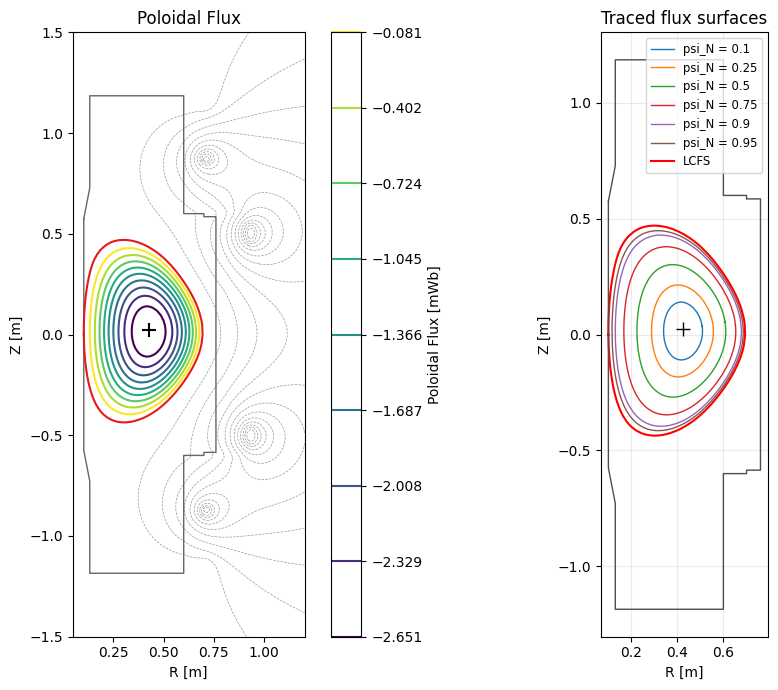

In [ ]:
from matplotlib.path import Path as MplPath

from vaft.process.equilibrium import extract_flux_surface_contours

traced = extract_flux_surface_contours(
    equilibrium.psi * factor, equilibrium.r, equilibrium.z,
    equilibrium.psi_axis * factor, equilibrium.psi_boundary * factor,
    [level for level in levels if 0.0 < level < 1.0],
)

fig, (ax_map, ax_traced) = plt.subplots(1, 2, figsize=(11, 7))

# Left: the canonical flux map, as any VAFT consumer would draw it.
vaft.omas.plot_equilibrium_field_psi(ods, label=[str(SHOT)], time_slice=index, ax=ax_map)

# Right: the surfaces the table above was computed on, at those exact levels.
# A level returns every segment at that flux value, open ones near the wall
# included; the confined surface is the closed segment enclosing the magnetic
# axis, which is the selection flux_surface_quantities makes from axis_rz.
def confined(segments, axis):
    closed = [
        (r_seg, z_seg) for r_seg, z_seg in segments
        if r_seg.size > 3
        and MplPath(np.column_stack([r_seg, z_seg])).contains_point(axis)
    ]
    return max(closed, key=lambda pair: pair[0].size) if closed else None

for level, segments in sorted(traced.items()):
    surface = confined(segments, equilibrium.magnetic_axis)
    if surface is None:
        print(f"psi_N = {level:g}: no confined segment")
        continue
    ax_traced.plot(surface[0], surface[1], lw=1.0, label=f"psi_N = {level:g}")
ax_traced.plot(equilibrium.lcfs.r, equilibrium.lcfs.z, color="red", lw=1.5, label="LCFS")
if equilibrium.limiter is not None:
    ax_traced.plot(equilibrium.limiter.r, equilibrium.limiter.z, color="0.3", lw=1.0)
ax_traced.plot(*equilibrium.magnetic_axis, "k+", ms=10)
ax_traced.set(xlabel="R [m]", ylabel="Z [m]", title="Traced flux surfaces")
ax_traced.set_aspect("equal", adjustable="box")
ax_traced.grid(alpha=0.25)
ax_traced.legend(fontsize="small", loc="upper right")
fig.tight_layout()
plt.show()

## MHD equilibrium interpretation

What the stability stages will ask of this equilibrium: where the low-order
rational surfaces sit, how sheared the q profile is, and whether a field line
started in the core stays confined. A rational surface outside the q range is
reported as absent, not interpolated into existence.

In [ ]:
print(f"q on axis {descriptors['q0'].value:.3f}, at the edge {descriptors['q_edge'].value:.3f}")
print()
# One q value can be crossed more than once, so each entry is a tuple of
# surfaces -- empty when the profile never reaches that q.
for q_value, found in sorted(descriptors.rational_surfaces.items()):
    if not found:
        print(f"  q = {q_value:<4g} not present in this profile")
        continue
    where = ", ".join(f"psi_N = {float(item.value):.4f}" for item in found if item.available)
    print(f"  q = {q_value:<4g} at {where}   [{found[0].provenance.method}]")

shear = descriptors["magnetic_shear"]
print()
if shear.available:
    values = np.asarray(shear.value, dtype=float)
    print(f"magnetic shear: {values.min():.3f} to {values.max():.3f} over the profile")
else:
    print("magnetic shear:", shear.reason)
print("definition:", shear.definition)

q on axis 2.460, at the edge 11.732

  q = 1    not present in this profile
  q = 1.5  not present in this profile
  q = 2    not present in this profile
  q = 3    at psi_N = 0.4132   [piecewise-linear root]

magnetic shear: 0.000 to 13.671 over the profile
definition: (rho_pol_n/q)*dq/drho_pol_n


field line from R=0.561 m: 30.0 m traced, 12.20 toroidal turns, stopped by max_length_m


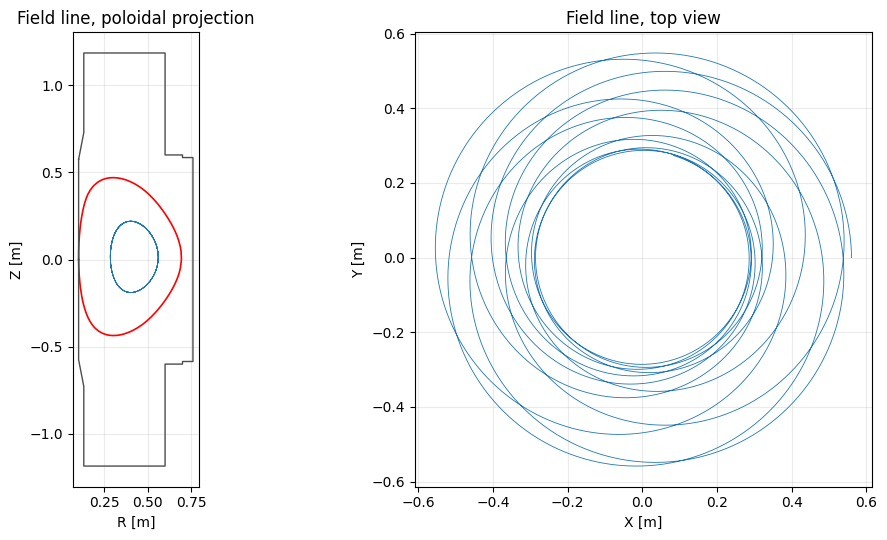

In [ ]:
b_field = make_equilibrium_field_interpolator(
    equilibrium.r, equilibrium.z, equilibrium.psi, equilibrium.psi_1d, equilibrium.f
)
start_r = 0.5 * (float(equilibrium.magnetic_axis[0]) + float(equilibrium.lcfs.r.max()))
line = trace_field_line(
    start_r, float(equilibrium.magnetic_axis[1]), 0.0, b_field,
    max_length_m=30.0,
    wall_r=equilibrium.limiter.r if equilibrium.limiter is not None else None,
    wall_z=equilibrium.limiter.z if equilibrium.limiter is not None else None,
)
print(f"field line from R={start_r:.3f} m: {line['arc_length_m'][-1]:.1f} m traced, "
      f"{line['phi'][-1] / (2 * np.pi):.2f} toroidal turns, stopped by {line['termination_reason']}")

fig, (ax_pol, ax_top) = plt.subplots(1, 2, figsize=(11, 5.5))
ax_pol.plot(line["R"], line["Z"], lw=0.6)
ax_pol.plot(equilibrium.lcfs.r, equilibrium.lcfs.z, color="red", lw=1.2)
if equilibrium.limiter is not None:
    ax_pol.plot(equilibrium.limiter.r, equilibrium.limiter.z, color="0.3", lw=1.0)
ax_pol.set(xlabel="R [m]", ylabel="Z [m]", title="Field line, poloidal projection")
ax_pol.set_aspect("equal", adjustable="box")

ax_top.plot(line["R"] * np.cos(line["phi"]), line["R"] * np.sin(line["phi"]), lw=0.6)
ax_top.set(xlabel="X [m]", ylabel="Y [m]", title="Field line, top view")
ax_top.set_aspect("equal", adjustable="box")
for ax in (ax_pol, ax_top):
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Outputs for stability analysis

DCON, RDCON and GPEC read a GEQDSK. VAFT writes one from the same ODS, and the
round trip is checked here rather than assumed: the descriptors derived from the
written file must match the descriptors derived from the ODS it came from.

In [ ]:
import tempfile
from pathlib import Path

from vaft.data.eqdsk import from_omas, read_geqdsk, write_geqdsk

with tempfile.TemporaryDirectory() as scratch:
    target = Path(scratch) / f"g{SHOT:06d}.{int(round(times[index] * 1e5)):05d}"
    write_geqdsk(from_omas(ods, time_index=index), target)
    print(f"{target.name}: {target.stat().st_size / 1024:.1f} kB")
    print(target.read_text().splitlines()[0])
    written = derive_global_descriptors(as_equilibrium(read_geqdsk(target)))

print()
print(f"{'quantity':22s} {'from ODS':>14s} {'from GEQDSK':>14s}")
for name in ("ip", "bt0", "major_radius", "minor_radius", "elongation", "volume", "q95"):
    left, right = descriptors[name], written[name]
    if left.available and right.available:
        print(f"{name:22s} {float(left.value):14.6g} {float(right.value):14.6g}")
    else:
        print(f"{name:22s} {'--':>14s} {'--':>14s}")

g039915.31600: 277.7 kB
EFIT     02/26/2026    # 39915   331ms             0 129 129

quantity                     from ODS    from GEQDSK
ip                            80065.5        80065.5
bt0                          0.149585       0.149585
major_radius                 0.398943       0.398943
minor_radius                 0.294873       0.294873
elongation                    1.53617        1.53617
volume                        0.95592        0.95592
q95                           8.67062        8.67062


## What this page establishes

- One equilibrium, loaded and validated against its own stated convention, with
  the ambiguity reported rather than resolved by assumption.
- Scalars, profiles, flux-surface averages and radial coordinates derived
  through `vaft.process.equilibrium`, each carrying its unit and provenance.
- A GEQDSK handoff whose descriptors round-trip, which is what the stability
  stages consume.

The same calls work on any equilibrium VAFT can load -- a database shot, an IMAS
netCDF entry, or another machine's public file, as
`multiple_tokamak_comparison.ipynb` shows.